# 04 Disk-integrated intensity mapping

# 04 原子柱圆盘积分强度 mapping

这个 notebook 承接 `01_Findatom.ipynb` 保存的原子柱定位、分类、精修和 curation 结果，使用固定半径圆盘对每个原子柱附近像素强度求和，并输出 intensity mapping 和 histogram。

边界说明：这里不做自动 vacancy 判定，不设置 vacancy threshold，不做背景扣除、annulus background、Gaussian weighting/fitting、heatmap interpolation、intensity ratio map 或 composition inference。

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'src' / 'em_atom_workbench').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
PROJECT_SRC = str(PROJECT_ROOT / 'src')
if PROJECT_SRC in sys.path:
    sys.path.remove(PROJECT_SRC)
sys.path.insert(0, PROJECT_SRC)
for module_name in list(sys.modules):
    if module_name == 'em_atom_workbench' or module_name.startswith('em_atom_workbench.'):
        del sys.modules[module_name]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from em_atom_workbench import (
    AnalysisROI,
    DiskIntensityConfig,
    compute_disk_intensity_table,
    initialize_analysis_workspace,
    load_active_workspace_session,
    load_stage_session,
    plot_disk_aperture_preview,
    plot_disk_intensity_histogram,
    plot_disk_intensity_map,
    summarize_disk_intensity,
)
from em_atom_workbench.notebook_workflows import (
    export_disk_intensity_analysis,
    initialize_disk_intensity_analysis,
)

plt.rcParams['figure.dpi'] = 140
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans', 'Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

## 0. Workspace parameters

这一格只定义当前 dataset/run 的统一 workspace。04 默认从 `workspace/state/sessions/01_final_curated.pkl` 读取 01 的最终 curated session，并把所有 04 输出写入 canonical `04_intensity_mapping/`。

In [23]:
OUTPUT_ROOT = PROJECT_ROOT / 'results'
DATASET_ID = 'dataset_001'
ANALYSIS_ID = 'run_001_2'

workspace = initialize_analysis_workspace(
    output_root=OUTPUT_ROOT,
    dataset_id=DATASET_ID,
    analysis_id=ANALYSIS_ID,
)

RESULT_ROOT = workspace.root

print(f'workspace: {workspace.root}')
print(f'04 output: {workspace.root / "04_intensity_mapping"}')

workspace: d:\LIANGKUAN\PolyU-PhD\Reserch\HfO2\code\Python\atom_analysis_manual\results\dataset_001\run_001_2
04 output: d:\LIANGKUAN\PolyU-PhD\Reserch\HfO2\code\Python\atom_analysis_manual\results\dataset_001\run_001_2\04_intensity_mapping


## 1. Session input parameters

读取优先级固定为：`SESSION_PATH > USE_ACTIVE_SESSION > SESSION_SOURCE`。

In [24]:
# SESSION_SOURCE：
# 默认读取 workspace/state/sessions/01_final_curated.pkl。
# 这是 Notebook01 完成最终 curation 后保存的推荐入口。
SESSION_SOURCE = '01_final_curated'

# SESSION_PATH：
# 如果你要读取某个手动保存的 session pickle，可以在这里填路径。
# 只要 SESSION_PATH 非 None，就会优先使用它。
SESSION_PATH = "D:/LIANGKUAN/PolyU-PhD/Reserch/HfO2/code/Python/atom_analysis_manual/results/_active_session.pkl"

# USE_ACTIVE_SESSION：
# True 时读取 workspace/state/active_session.pkl。
# 这适合继续当前 workspace 中最新状态，但正式复现建议使用明确 stage session。
USE_ACTIVE_SESSION = False

print('session priority: SESSION_PATH > USE_ACTIVE_SESSION > SESSION_SOURCE')
print(f'default stage session: {workspace.sessions_dir / (SESSION_SOURCE + ".pkl")}')
print(f'active session: {workspace.state_dir / "active_session.pkl"}')

session priority: SESSION_PATH > USE_ACTIVE_SESSION > SESSION_SOURCE
default stage session: d:\LIANGKUAN\PolyU-PhD\Reserch\HfO2\code\Python\atom_analysis_manual\results\dataset_001\run_001_2\state\sessions\01_final_curated.pkl
active session: d:\LIANGKUAN\PolyU-PhD\Reserch\HfO2\code\Python\atom_analysis_manual\results\dataset_001\run_001_2\state\active_session.pkl


## 2. Coordinate source

这里选择用于 disk intensity integration 的坐标来源。默认使用 Gaussian-refined coordinates。

In [25]:
# COORDINATE_SOURCE：
# 选择用于 disk intensity integration 的原子坐标来源。
#
# - "candidate"：
# 使用 01 中粗检 + napari 人工复核后的 candidate_points。
# 适合检查低强度/疑似空位柱，因为 Gaussian fitting 可能在弱柱或异常柱上发生偏移。
#
# - "refined"：
# 使用 Gaussian fitting 后的 refined_points。
# 适合正常原子柱的亚像素精确强度积分，是多数正式强度 mapping 的推荐选择。
#
# - "curated"：
# 使用最终 curated_points，通常是 refined 后再经过 keep/filter/quality 筛选的结果。
# 适合只分析最终保留下来的点。
#
# 对于疑似 vacancy / low-intensity columns：
# 建议分别运行 candidate 和 refined 两套坐标结果进行对比。
# 如果低强度点在 refined 坐标下明显偏移或消失，说明 Gaussian fitting 可能受弱强度/邻近柱影响。
COORDINATE_SOURCE = 'refined'  # 'candidate', 'refined', or 'curated'

# USE_KEEP_ONLY：只在所选坐标表存在 keep 列时应用；没有 keep 列会自动跳过。
USE_KEEP_ONLY = True

## 3. Image / atom / ROI selection

04 第一版只做固定半径圆盘积分。建议低强度检查时先只分析一个明确 sublattice/class，避免混合不同 class 的强度分布。

In [ ]:
IMAGE_CHANNEL = None
IMAGE_KEY = 'raw'

# TARGET_CLASS_IDS / TARGET_CLASS_NAMES：
# 用于选择要做 intensity mapping 的原子柱类别。
# 对低强度/疑似空位分析，推荐先只分析一个明确 sublattice/class，不要混合不同 class。
TARGET_CLASS_IDS = [0]
TARGET_CLASS_NAMES = None

# ROIS=None 使用 global ROI。
# 如果需要手动限制区域，可传入 AnalysisROI 列表；本 notebook 不打开 napari ROI picker。
ROIS = None

## 4. Initialize analysis context

这一格读取 session、解析图像、准备选定坐标源的原子点表，并显示当前 session/source 信息。

In [11]:
context = initialize_disk_intensity_analysis(
    session_path=SESSION_PATH,
    workspace=workspace,
    session_source=SESSION_SOURCE,
    use_active_session=USE_ACTIVE_SESSION,
    result_root=RESULT_ROOT,
    coordinate_source=COORDINATE_SOURCE,
    use_keep_only=USE_KEEP_ONLY,
    class_id_filter=TARGET_CLASS_IDS,
    class_filter=TARGET_CLASS_NAMES,
    rois=ROIS,
    image_channel=IMAGE_CHANNEL,
    image_key=IMAGE_KEY,
)

session = context['session']
points = context['points']
image = context['image']
output_dirs = context['output_dirs']
preview_figures = {}
final_figures = {}

display(context['summary_tables']['disk_intensity_setup_summary'])
display(points.head())
print(f'coordinate_source: {context["coordinate_source"]}')
print(f'source_table: {context["source_table"]}')
print(f'session_load_mode: {context["session_load_mode"]}')
print(f'resolved_session_path: {context["resolved_session_path"]}')

,field,value
0,session_name,2
1,current_stage,curated
2,session_load_mode,session_path
3,resolved_session_path,D:\LIANGKUAN\PolyU-PhD\Reserch\HfO2\code\Pytho...
4,coordinate_source,refined
5,source_table,refined_points
6,image_channel,Ptycho_DW1
7,image_key,raw
8,point_rows,770
9,unique_points,770


,point_id,atom_id,x_px,y_px,x_nm,y_nm,class_id,class_name,class_color,roi_id,roi_name,roi_color,scope_id,keep,coordinate_source,source_table,source_type,point_set
0,atom:76,76,660.937370,277.097502,10.261625,4.302179,1,class_1,#f18f01,global,global,#ff9f1c,global:atoms:refined_points,True,refined,refined_points,atom,atoms
1,atom:89,89,475.110273,374.882706,7.376498,5.820378,1,class_1,#f18f01,global,global,#ff9f1c,global:atoms:refined_points,True,refined,refined_points,atom,atoms
2,atom:111,111,480.087933,35.077224,7.453781,0.544604,1,class_1,#f18f01,global,global,#ff9f1c,global:atoms:refined_points,True,refined,refined_points,atom,atoms
3,atom:124,124,269.089880,596.961662,4.177853,9.268346,1,class_1,#f18f01,global,global,#ff9f1c,global:atoms:refined_points,True,refined,refined_points,atom,atoms
4,atom:125,125,368.931381,415.126236,5.727979,6.445194,1,class_1,#f18f01,global,global,#ff9f1c,global:atoms:refined_points,True,refined,refined_points,atom,atoms


coordinate_source: refined
source_table: refined_points
session_load_mode: session_path
resolved_session_path: D:\LIANGKUAN\PolyU-PhD\Reserch\HfO2\code\Python\atom_analysis_manual\results\_active_session.pkl


## 5. Preview selected points

这一格只显示已选点的数量、class 和 ROI 分布，用于确认 filtering 后的分析对象。

In [12]:
point_summary_rows = [
    {'field': 'rows', 'value': len(points)},
    {'field': 'unique_points', 'value': points['point_id'].nunique() if 'point_id' in points else len(points)},
    {'field': 'coordinate_source', 'value': COORDINATE_SOURCE},
    {'field': 'source_table', 'value': context['source_table']},
]
display(pd.DataFrame(point_summary_rows))
if 'class_name' in points:
    display(points['class_name'].fillna('class_unknown').astype(str).value_counts().rename_axis('class_name').reset_index(name='count'))
if 'roi_id' in points:
    display(points['roi_id'].fillna('global').astype(str).value_counts().rename_axis('roi_id').reset_index(name='count'))

,field,value
0,rows,770
1,unique_points,770
2,coordinate_source,refined
3,source_table,refined_points


,class_name,count
0,class_1,770


,roi_id,count
0,global,770


## 6. Disk radius parameters

半径太小会受单像素噪声影响大；半径太大可能混入邻近原子柱。建议根据实际原子柱宽度和间距调整。

In [13]:
DISK_RADIUS_PX = 2.0

## 7. Aperture preview

预览少量点周围的积分圆盘，检查 `DISK_RADIUS_PX` 是否合理。Preview figure 默认不保存。

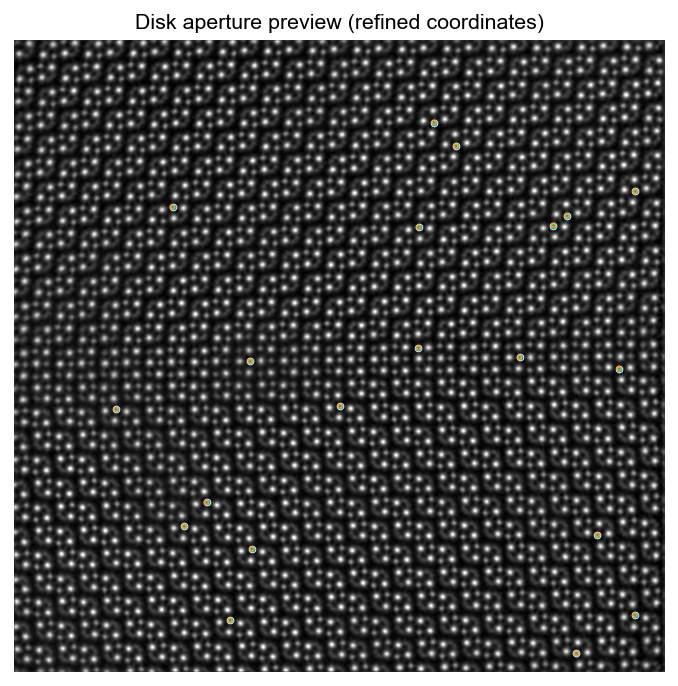

In [14]:
fig, ax = plot_disk_aperture_preview(
    image,
    points,
    disk_radius_px=DISK_RADIUS_PX,
    max_points=20,
    random_seed=0,
    show_axes=False,
    title=f'Disk aperture preview ({COORDINATE_SOURCE} coordinates)',
)
preview_figures['04A_disk_aperture_preview'] = fig
display(fig)
plt.close(fig)

## 8. Run disk intensity calculation

这里执行唯一的核心计算：固定半径圆盘内像素强度求和。不做背景扣除、不做归一化、不做 threshold。

In [15]:
disk_config = DiskIntensityConfig(
    image_channel=context['image_channel'],
    image_key=IMAGE_KEY,
    disk_radius_px=DISK_RADIUS_PX,
    coordinate_source=COORDINATE_SOURCE,
    use_keep_only=USE_KEEP_ONLY,
)

intensity_table = compute_disk_intensity_table(
    points,
    image,
    disk_radius_px=disk_config.disk_radius_px,
    channel_name=context['image_channel'],
    image_key=disk_config.image_key,
    coordinate_source=disk_config.coordinate_source,
)

summary_table = summarize_disk_intensity(
    intensity_table,
    group_by=('coordinate_source', 'class_id', 'class_name', 'channel_name'),
    metric='disk_intensity_sum',
)

## 9. Display intensity table and summary

In [16]:
display(intensity_table.head())
display(summary_table)
print(f'coordinate_source: {COORDINATE_SOURCE}')
print(f'disk_radius_px: {DISK_RADIUS_PX}')

,point_id,atom_id,x_px,y_px,x_nm,y_nm,class_id,class_name,class_color,roi_id,...,source_table,disk_radius_px,n_pixels,disk_intensity_sum,disk_intensity_mean,is_edge,status,keep,source_type,point_set
0,atom:76,76,660.937370,277.097502,10.261625,4.302179,1,class_1,#f18f01,global,...,refined_points,2.0,11,1365.0,124.090909,False,ok,True,atom,atoms
1,atom:89,89,475.110273,374.882706,7.376498,5.820378,1,class_1,#f18f01,global,...,refined_points,2.0,11,1410.0,128.181818,False,ok,True,atom,atoms
2,atom:111,111,480.087933,35.077224,7.453781,0.544604,1,class_1,#f18f01,global,...,refined_points,2.0,11,1386.0,126.000000,False,ok,True,atom,atoms
3,atom:124,124,269.089880,596.961662,4.177853,9.268346,1,class_1,#f18f01,global,...,refined_points,2.0,11,1419.0,129.000000,False,ok,True,atom,atoms
4,atom:125,125,368.931381,415.126236,5.727979,6.445194,1,class_1,#f18f01,global,...,refined_points,2.0,11,1439.0,130.818182,False,ok,True,atom,atoms


,coordinate_source,class_id,class_name,channel_name,count,mean,std,median,q25,q75,min,max
0,refined,1,class_1,Ptycho_DW1,770,1452.881818,155.337789,1479.0,1360.25,1567.75,825.0,1732.0


coordinate_source: refined
disk_radius_px: 2.0


## 10. Intensity map parameters

In [17]:
MAP_METRIC = 'disk_intensity_sum'
MAP_CMAP = 'viridis'
MAP_POINT_SIZE = 32
MAP_EDGE_COLOR_MODE = 'class'  # 'class', 'fixed', 'none'
MAP_FIXED_EDGECOLOR = 'white'

## 11. Plot intensity map

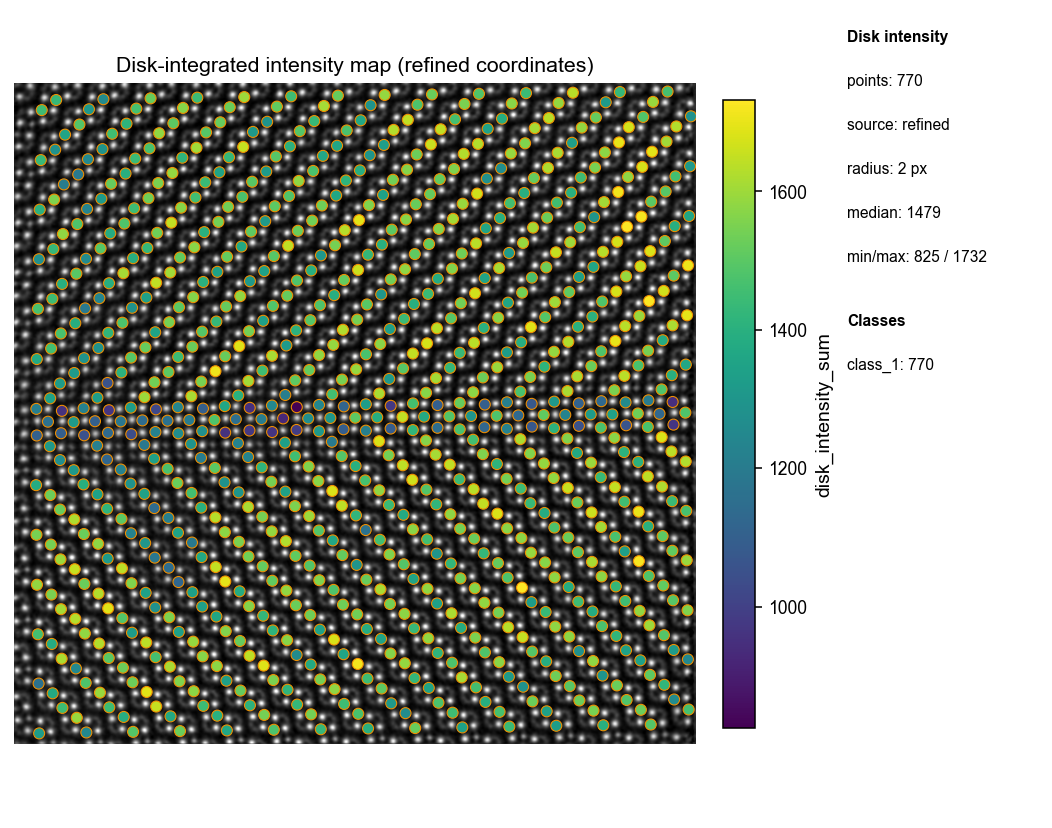

In [18]:
map_result = plot_disk_intensity_map(
    image,
    intensity_table,
    metric=MAP_METRIC,
    cmap=MAP_CMAP,
    point_size=MAP_POINT_SIZE,
    show_colorbar=True,
    show_axes=False,
    title=f'Disk-integrated intensity map ({COORDINATE_SOURCE} coordinates)',
    show_side_panel=True,
    show_roi_outlines=True,
    rois=ROIS,
    edgecolor_mode=MAP_EDGE_COLOR_MODE,
    fixed_edgecolor=MAP_FIXED_EDGECOLOR,
)
fig = map_result[0]
final_figures['04A_disk_intensity_map'] = fig
display(fig)
plt.close(fig)

## 12. Histogram parameters

In [19]:
HIST_METRIC = 'disk_intensity_sum'
HIST_BINS = 30
HIST_GROUP_BY_CLASS = True
HIST_GROUP_BY_ROI = False

## 13. Plot histogram

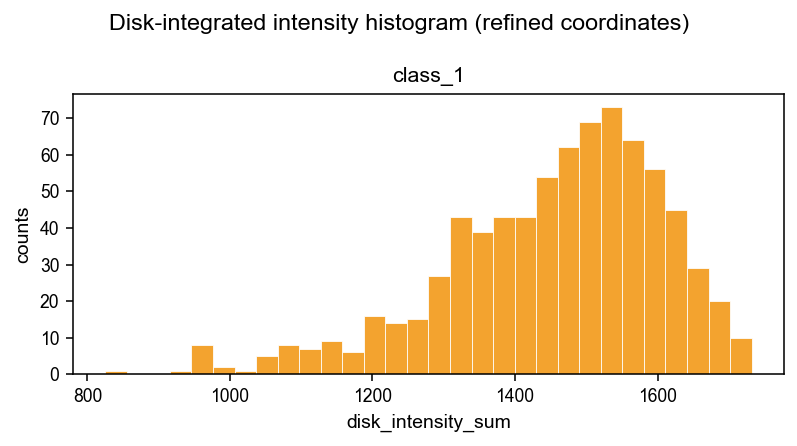

In [20]:
fig, axes = plot_disk_intensity_histogram(
    intensity_table,
    metric=HIST_METRIC,
    bins=HIST_BINS,
    group_by_class=HIST_GROUP_BY_CLASS,
    group_by_roi=HIST_GROUP_BY_ROI,
    title=f'Disk-integrated intensity histogram ({COORDINATE_SOURCE} coordinates)',
)
final_figures['04B_disk_intensity_histogram'] = fig
display(fig)
plt.close(fig)

## 14. Final export parameters

In [21]:
SAVE_PREVIEW_FIGURES = False
SAVE_FINAL_FIGURES = True

FIGURE_FORMATS = ('pdf', 'png', 'svg')
FIGURE_DPI = 600
FIGURE_FONT_FAMILY = 'Arial'
FIGURE_FONT_SIZE = 9

FIG_04A = {
    'save': True,
    'title': f'Disk-integrated intensity map ({COORDINATE_SOURCE} coordinates)',
    'show_title': True,
    'formats': FIGURE_FORMATS,
    'dpi': FIGURE_DPI,
    'font_family': FIGURE_FONT_FAMILY,
    'font_size': FIGURE_FONT_SIZE,
}

FIG_04B = {
    'save': True,
    'title': f'Disk-integrated intensity histogram ({COORDINATE_SOURCE} coordinates)',
    'show_title': True,
    'formats': FIGURE_FORMATS,
    'dpi': FIGURE_DPI,
    'font_family': FIGURE_FONT_FAMILY,
    'font_size': FIGURE_FONT_SIZE,
}

FINAL_FIGURE_SPECS = {
    '04A_disk_intensity_map': FIG_04A,
    '04B_disk_intensity_histogram': FIG_04B,
}

## 15. Export results

导出 CSV、figure、config、manifest 和 04 stage session，并更新 workspace active session。

In [22]:
disk_intensity_export_config = {
    'dataset_id': DATASET_ID,
    'analysis_id': ANALYSIS_ID,
    'session_source': SESSION_SOURCE,
    'session_path': None if SESSION_PATH is None else str(SESSION_PATH),
    'use_active_session': USE_ACTIVE_SESSION,
    'session_load_mode': context['session_load_mode'],
    'resolved_session_path': context['resolved_session_path'],
    'coordinate_source': COORDINATE_SOURCE,
    'source_table': context['source_table'],
    'use_keep_only': USE_KEEP_ONLY,
    'image_channel': context['image_channel'],
    'image_key': IMAGE_KEY,
    'target_class_ids': TARGET_CLASS_IDS,
    'target_class_names': TARGET_CLASS_NAMES,
    'disk_radius_px': DISK_RADIUS_PX,
    'map_metric': MAP_METRIC,
    'histogram_metric': HIST_METRIC,
    'histogram_bins': HIST_BINS,
    'histogram_group_by_class': HIST_GROUP_BY_CLASS,
    'histogram_group_by_roi': HIST_GROUP_BY_ROI,
    'save_preview_figures': SAVE_PREVIEW_FIGURES,
    'save_final_figures': SAVE_FINAL_FIGURES,
    'figure_formats': FIGURE_FORMATS,
    'figure_dpi': FIGURE_DPI,
}

manifest = export_disk_intensity_analysis(
    workspace=workspace,
    result_root=RESULT_ROOT,
    session=session,
    intensity_table=intensity_table,
    summary_table=summary_table,
    config=disk_intensity_export_config,
    preview_figures=preview_figures,
    final_figures=final_figures,
    save_preview_figures=SAVE_PREVIEW_FIGURES,
    save_final_figures=SAVE_FINAL_FIGURES,
    figure_specs=FINAL_FIGURE_SPECS,
)
display(manifest)

{'workflow': 'disk_integrated_intensity_mapping',
 'stage_name': '04_intensity_mapping',
 'builder_script': 'scripts/build_04_disk_integrated_intensity_notebook.py',
 'notebook_name': '04_Disk_integrated_intensity_mapping.ipynb',
 'output_dir': 'd:\\LIANGKUAN\\PolyU-PhD\\Reserch\\HfO2\\code\\Python\\atom_analysis_manual\\results\\dataset_001\\run_001\\04_intensity_mapping',
 'session_source': '01_final_curated',
 'session_path': 'D:/LIANGKUAN/PolyU-PhD/Reserch/HfO2/code/Python/atom_analysis_manual/results/_active_session.pkl',
 'use_active_session': False,
 'coordinate_source': 'refined',
 'source_table': 'refined_points',
 'disk_radius_px': 2.0,
 'tables': {'disk_intensity_table': 'd:\\LIANGKUAN\\PolyU-PhD\\Reserch\\HfO2\\code\\Python\\atom_analysis_manual\\results\\dataset_001\\run_001\\04_intensity_mapping\\tables\\disk_intensity_table.csv',
  'disk_intensity_summary': 'd:\\LIANGKUAN\\PolyU-PhD\\Reserch\\HfO2\\code\\Python\\atom_analysis_manual\\results\\dataset_001\\run_001\\04_int